In [4]:
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import connected_components, shortest_path
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist


In [49]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q}

def graph_degree_density(Psi, h, delta=None, C=1, qtl=None):
    Dsq = squareform(pdist(Psi)**2)
    Wm = np.exp(-Dsq/h); rho = Wm.sum(1)
    rho = rho / rho.mean()
    if delta is None:
        if qtl is None: 
            delta = np.quantile(rho, 0.01)
        else:
            delta = np.quantile(rho, qtl)
    rho = np.maximum(C*rho, delta); V = -np.log(rho)
    return rho, V, delta


df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
Z = df.to_numpy()[:, :-1]; N = Z.shape[0]
dates = df.index; variables = df.columns
diff = diffusion_map(Z, eps=3, k=3); Psi = diff["Psi"]

Dsq_Psi = squareform(pdist(Psi) ** 2); median_Dsq = np.median(Dsq_Psi[Dsq_Psi > 0])
h = 0.1*median_Dsq; rho, V, DELTA = graph_degree_density(Psi, h=h, qtl=0.02)

TAU = np.median(squareform(pdist(Z)**2))

In [6]:
endpoint_pairs = {"GFC": ("2006-03-01", "2008-10-01"), "COVID": ("2019-07-01", "2020-04-01"), 
                  "Fiscal Tightening": ("2019-04-01", "2022-04-01"), "Recession Trough": ("1977-01-01", "1982-07-01")}

# Phase 5: Lifting paths back to macroeconomic variables

### 8.3 Linear lift for interpolated latent paths
I first code the preferred option, local neighbour lifting (LNL): 
$
\hat z(s) = \sum_{j\in\mathcal{N}_m(\gamma(s))}a_j(s)\tilde z_j
$

In [ ]:
def local_neighbourhood_lifting(Z, Psi, start_idx, end_idx, m=27, n_grid=10, tau=0.2):
    start_point, end_point = Psi[start_idx], Psi[end_idx]
    gamma = np.linspace(start_point, end_point, num=n_grid)
    nn = NearestNeighbors(n_neighbors=m); nn.fit(Psi)
    distances, indices = nn.kneighbors(gamma)
    a = np.exp(-distances**2/tau) / np.sum(np.exp(-distances**2 / tau), axis=1, keepdims=True)
    points = Z[indices, :]; z_hat = np.sum(a[:, :, None] * points, axis=1)
    z_hat[0], z_hat[-1] = Z[start_idx], Z[end_idx]
    return z_hat, gamma

Now the Baker et al. style lift $\hat z(s) = \mathbf{H}\gamma (s)$

In this form, there is no way for the least squares estimation to find an intercept so I centre the observations and add the mean back to the lifted coordinates

In [8]:
def lift_operator(Z, Psi):
    Z = Z - Z.mean()
    N = Psi.shape[0]; H = np.linalg.lstsq(Psi, Z, rcond=None)[0].T
    error_norm = np.linalg.norm(Z - Psi@H.T + Z.mean(), axis=1)**2
    RMSE = np.sqrt(np.sum(error_norm)/N)
    return H, RMSE

def baker_lift(Z, Psi, start_idx, end_idx, n_grid=10):
    H, _ = lift_operator(Z, Psi)
    start_point, end_point = Psi[start_idx], Psi[end_idx]

    gamma = np.linspace(start_point, end_point, num=n_grid)
    z_hat = gamma@H.T; z_hat += Z.mean()
    z_hat[0] = Z[start_idx]; z_hat[-1] = Z[end_idx]
    return z_hat, gamma

### 8.3 Lift validation

In [ ]:
def lift_validation(z_hat, Z):
    nn = NearestNeighbors(n_neighbors=1); nn.fit(Z)
    dNN, _ = nn.kneighbors(z_hat)
    return dNN

### Density of points in $\gamma(s)$

In [15]:
def latent_density_at_points(gamma, Psi, h, delta):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query_floor = np.maximum(rho_query, delta)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query

Finding the best value of m for the LNL method

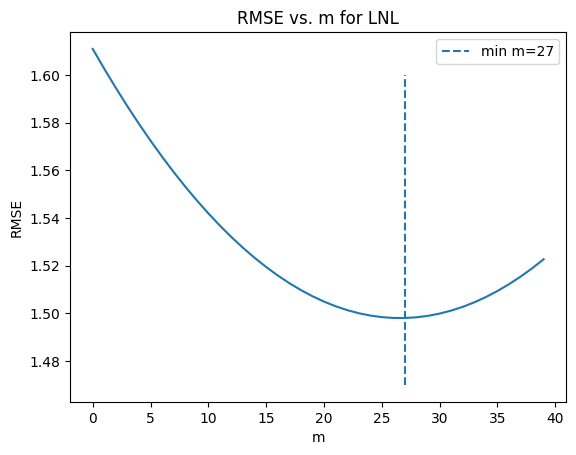

In [37]:
def lnl_error(Z, Psi, m=10, tau=0.2):
    N = Z.shape[0]; Z_hat = np.zeros_like(Z)
    for i in range(N):
        mask = np.ones(N, dtype=bool); mask[i] = 0
        Z_test = Z[mask]; Psi_test = Psi[mask]
        
        nn = NearestNeighbors(n_neighbors=m); nn.fit(Psi_test)
        distances, indices = nn.kneighbors(Psi[i].reshape(1,-1))
        a = np.exp(-distances**2/tau) / np.sum(np.exp(-distances**2 / tau), axis=1, keepdims=True)
        points = Z_test[indices, :]; Z_hat[i] = np.sum(a[:, :, None] * points, axis=1)

    obs_error = np.linalg.norm(Z - Z_hat, axis=1)
    RMSE = np.sqrt(np.mean(obs_error**2))
    return Z_hat, RMSE

rmses = []
for m in [5, 10, 15, 20, 30, 40]:
    _, RMSE = lnl_error(Z, Psi, m=m, tau=TAU)
    rmses.append(RMSE)
lbf = np.polyfit([5, 10, 15, 20, 30, 50], rmses, deg=2)
xs = np.linspace(0, 50, 40); line = lbf[2] + xs*lbf[1] + lbf[0]*xs**2
min_m = np.argmin(line)
plt.plot(line); plt.title("RMSE vs. m for LNL"); plt.ylabel("RMSE"); plt.xlabel("m")
plt.vlines(min_m, ymin=1.47, ymax=1.6, linestyles="--", label=f'min m={min_m}')
plt.legend(); plt.show()

### 8.4 Requred Phase 5 outputs

### (c) Lift reconstruction diagnostics.
For the Baker style lift method, I can simply report the RMSE calculated in the function which finds $H$, for the local neighbour lifting method I will test how good the lifting of each diffusion coordinate is.

$$\text{RMSE}_\text{lift,bkr}=\bigl(\frac{1}{N}\sum_{i=1}^{N}\|z_i - \hat z_i^{\text{(bkr)}}\|^2\bigr)^{1/2},$$
where $\hat z_i^{\text{(bkr)}} = (H\psi_i + \bar z).$

$$\text{RMSE}_\text{lift,lnl}=\bigl(\frac{1}{N}\sum_{i=1}^{N}\|z_i - z_i^\text{(lnl)}\|^2\bigr)^{1/2},$$
where $\hat z_i^\text{(lnl)} = \sum_{j\in\mathcal{N}_m(\gamma(t_i))}a_j(t_i)\tilde z_j.$


In [60]:
Z_mean = Z.mean(axis=0); Zmm = np.sum((Z - Z_mean) ** 2)
N, D = Z.shape

baseline_RMSE = np.sqrt(Zmm / N)
H, baker_RMSE = lift_operator(Z, Psi); Z_hat_baker = Psi @ H.T + Z_mean
Z_hat_lnl, lnl_RMSE = lnl_error(Z, Psi, m=27, tau=TAU)

SSE_baker = np.sum((Z - Z_hat_baker) ** 2); SSE_lnl = np.sum((Z - Z_hat_lnl) ** 2)
R2_baker = 1 - SSE_baker / Zmm; R2_lnl = 1 - SSE_lnl / Zmm

baker_RMSE_per_var = baker_RMSE / np.sqrt(D)
lnl_RMSE_per_var = lnl_RMSE / np.sqrt(D)
baseline_RMSE_per_var = baseline_RMSE / np.sqrt(D)

summary = pd.DataFrame({
    "Method": ["Mean baseline", "Baker linear lift", "Local-neighbour lift"],
    "RMSE": [baseline_RMSE, baker_RMSE, lnl_RMSE],
    "RMSE_per_variable": [baseline_RMSE_per_var, baker_RMSE_per_var, lnl_RMSE_per_var],
    "R2": [0.0, R2_baker, R2_lnl],
})

display(summary)

,Method,RMSE,RMSE_per_variable,R2
0,Mean baseline,1.938805,0.289020,0.000000
1,Baker linear lift,1.515567,0.225927,0.388939
2,Local-neighbour lift,1.515221,0.225876,0.389222


Both the local neighbour lifing (LNL) and the Baker-style lifing perform better than just choosing the mean value of the macro data cloud. The LNL method works ever so slighly better on this training set, despite using leave-one-out sampling (unlike the Baker-style error which uses in-sample testing). We are however computing the 27 nearest neigbours and the Gaussian weights for each of them. This might end up being quite expensive? Without optimising for the number of neighbours, the LNL method performed slighltly worse than the Baker-style method. There is no conclusive evidence here to suggest either method is superior.

A possible avenue of exploration is seeing whether the Baker-style linear decoder performs very well for the dense central region of the macro cloud, where most observations lie and where a global linear approximation is adequate. Whereas the LNL method may be more useful near sparse or stressed regions, because it reconstructs points from nearby historical states rather than imposing a single global linear map. This will be checked by comparing reconstruction errors across density quantiles and along the selected stress paths.

### Testing in high-density vs. low-density

In [68]:
sparsity_threshold = np.quantile(V, 0.80)
mask_sparse = V > sparsity_threshold

n_sparse = mask_sparse.sum()
n_dense = (~n_sparse).sum()

Z_mean = Z.mean(axis=0)

H, _ = lift_operator(Z, Psi)
Z_hat_baker = Psi @ H.T + Z_mean

Z_hat_lnl, _ = lnl_error(Z, Psi, m=27, tau=TAU)

def group_rmse(Z_true, Z_pred, mask):
    return np.sqrt(np.sum((Z_true[mask] - Z_pred[mask])**2) / mask.sum())

RMSE_bkr_dense = group_rmse(Z, Z_hat_baker, ~mask_sparse)
RMSE_bkr_sparse = group_rmse(Z, Z_hat_baker, mask_sparse)

RMSE_lnl_dense = group_rmse(Z, Z_hat_lnl, ~mask_sparse)
RMSE_lnl_sparse = group_rmse(Z, Z_hat_lnl, mask_sparse)

print("Baker dense:", RMSE_bkr_dense)
print("Baker sparse:", RMSE_bkr_sparse)
print("LNL dense:", RMSE_lnl_dense)
print("LNL sparse:", RMSE_lnl_sparse)

Baker dense: 1.5078873758557312
Baker sparse: 1.5458263314763496
LNL dense: 1.5043984791911948
LNL sparse: 1.5576194504494068


These are not the results I was expecting. This shows that both methods work better in dense regions and the Baker-style method works marginally better than the LNL method. This could be due to the fact that for LNL, in sparse regions the 'local' neigbours are not very closeby, and so averaging over their positions doesn't work as well. On the other hand the macro space may be well suited to the linear approximation by the Baker-style method, meaning that liftings in sparse regions are less sensitive to far away neigbours. This is all quite hand wavy, and there really doesn't seem to be much evidence that either method is actually that much better than the other, but I thought I'd put some thoughts down incase I want to revisit this.


### (a) / (d) Generating paths / Plausablilty diagnostics

In [91]:
idx_pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

lifted_paths = {name: {"LNL": None, "baker": None, "lnl_validation": None, "baker_validation": None, "density": None} for name in idx_pairs.keys()}

for event, (start_idx, end_idx) in idx_pairs.items():
    z_lnl, gamma = local_neighbourhood_lifting(Z, Psi, start_idx, end_idx, m=27, tau=TAU, n_grid=10)
    z_baker, _ = baker_lift(Z, Psi, start_idx, end_idx, n_grid=10)
    lifted_paths[event]["LNL"] = z_lnl
    lifted_paths[event]["baker"] = z_baker
    lifted_paths[event]["lnl_validation"] = (lift_validation(z_lnl, Z))
    lifted_paths[event]["baker_validation"] = (lift_validation(z_baker, Z))
    lifted_paths[event]["density"] = (latent_density_at_points(gamma, Psi, h=h, delta=DELTA))


In [92]:
DZ = squareform(pdist(Z))
np.fill_diagonal(DZ, np.inf)

d_Z = np.min(DZ, axis=1)

d_Z_median = np.median(d_Z)
d_Z_95 = np.quantile(d_Z, 0.95)

rows = []

for event in lifted_paths.keys():
    d_lnl = np.ravel(lifted_paths[event]["lnl_validation"])[1:-1]
    d_baker = np.ravel(lifted_paths[event]["baker_validation"])[1:-1]

    rows.append({"event": event, "path_type": "LNL", "median_dNN": np.median(d_lnl), "95%_dNN": np.quantile(d_lnl, 0.95), 
                 "max_dNN": np.max(d_lnl), "historical_median_dNN": d_Z_median, "historical_95%_dNN": d_Z_95})

    rows.append({"event": event, "path_type": "Baker", "median_dNN": np.median(d_baker), "95%_dNN": np.quantile(d_baker, 0.95),
                 "max_dNN": np.max(d_baker), "historical_median_dNN": d_Z_median, "historical_95%_dNN": d_Z_95})

plausibility_df = pd.DataFrame(rows)
display(plausibility_df)

,event,path_type,median_dNN,95%_dNN,max_dNN,historical_median_dNN,historical_95%_dNN
0,GFC,LNL,1.161019,1.220011,1.220064,1.467997,1.783956
1,GFC,Baker,1.619798,2.950735,3.142251,1.467997,1.783956
2,COVID,LNL,1.140342,1.267517,1.280149,1.467997,1.783956
3,COVID,Baker,1.146454,1.299011,1.311120,1.467997,1.783956
4,Fiscal Tightening,LNL,1.171237,1.187037,1.189019,1.467997,1.783956
5,Fiscal Tightening,Baker,1.127231,1.202932,1.230748,1.467997,1.783956
6,Recession Trough,LNL,1.104318,1.165256,1.184029,1.467997,1.783956
7,Recession Trough,Baker,1.181524,1.216778,1.218609,1.467997,1.783956


In this test we can see that the local-neighbour lift performs better than the Baker-style lift on every metric (apart from `median_dNN` for 'Fiscal Tightening'). All of the results suggest that both of these methods work reasonable well, apart from for the Global Financial Crisis path with the Baker-style lift, where the 95% quantile of the distance to the closest neigbour is ~3 compared to the historic 95% quantile of ~1.8. This shows that the Baker-style lifting may not be suitable for all stress scenarios.

### (b) Plots of selected macro variables along each path.
I chose 1 macroeconomic variable from each of the following categories: 
- Output and activity  
- Employment
- Inflation
- Interest rates and term spreads
- Credit spreads
- Money and liquidity
- Financial market stress proxies
- Housing

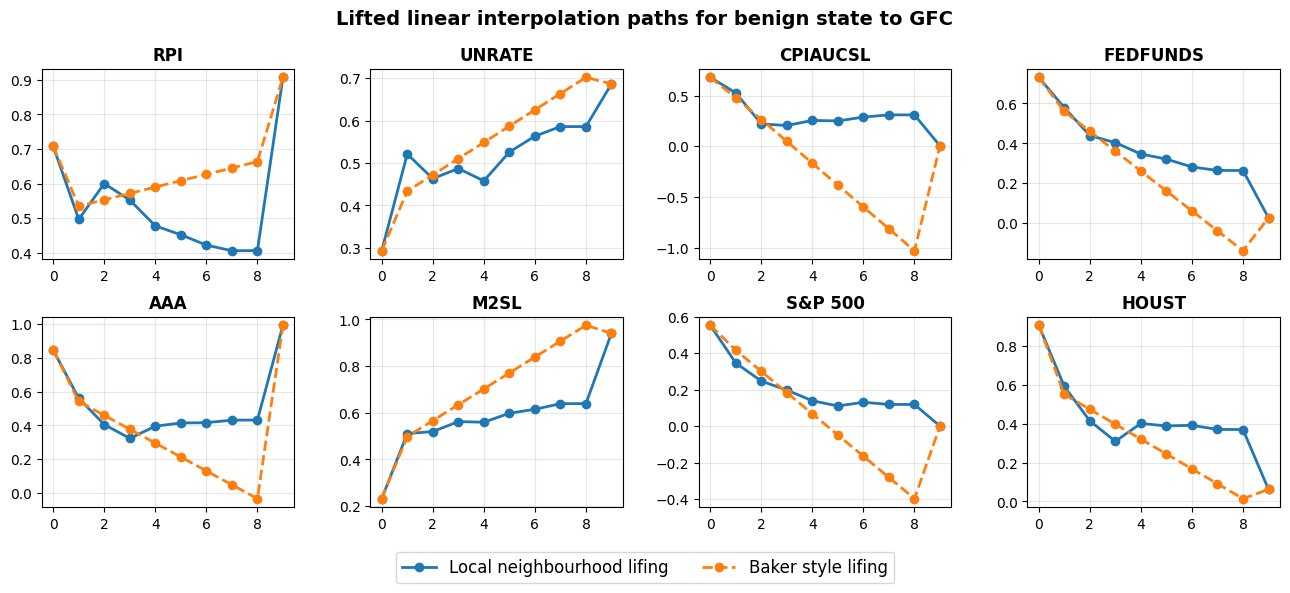

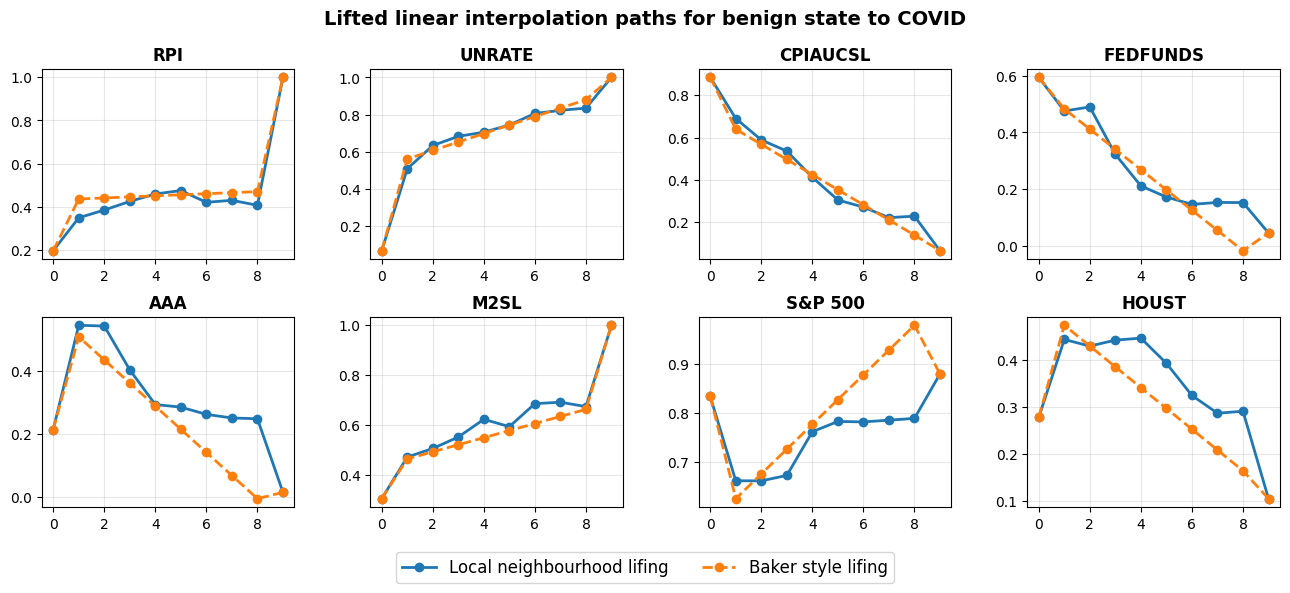

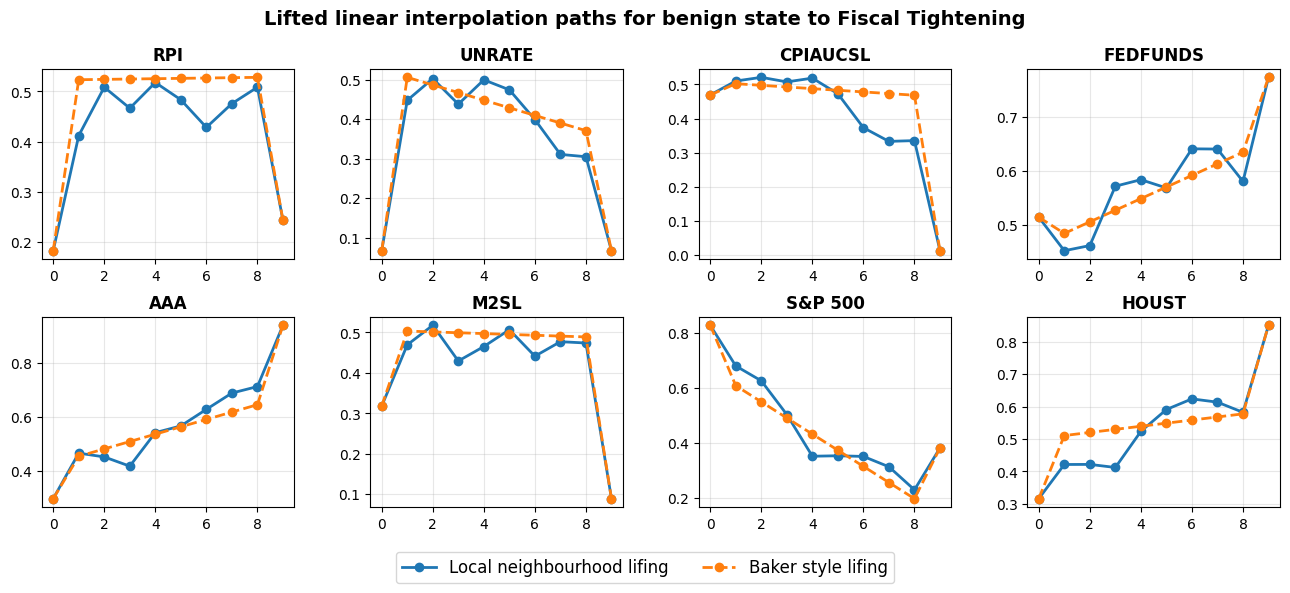

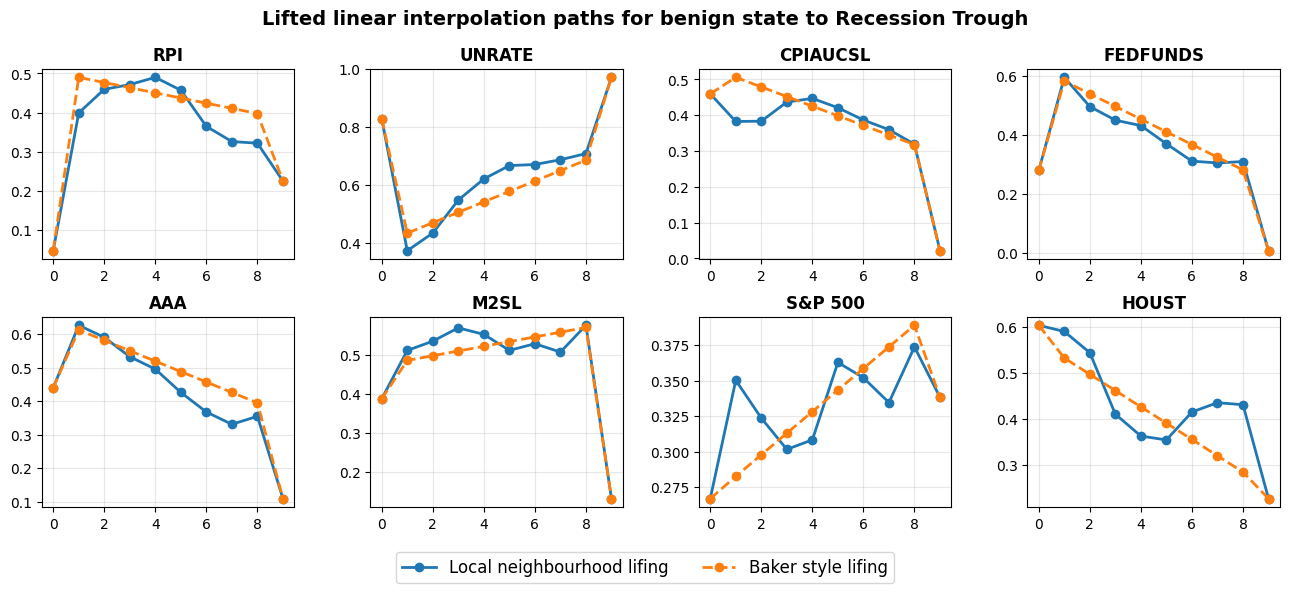

In [99]:
selected_vars = ['RPI', 'UNRATE', 'CPIAUCSL', 'FEDFUNDS', 'AAA', 'M2SL', 'S&P 500', 'HOUST']
selected_idxs = [variables.get_loc(col) for col in selected_vars]

for event in lifted_paths.keys():
    local_neighbour_path = lifted_paths[event]["LNL"]
    baker_path = lifted_paths[event]["baker"]

    fig, axes = plt.subplots(2, 4, figsize=(13, 6))
    axes_flat = axes.flatten()

    for i, var in enumerate(selected_idxs):
        ax = axes_flat[i]
        ax.plot(local_neighbour_path[:, var], marker="o", linewidth=2)
        ax.plot(baker_path[:, var], marker="o", linewidth=2, linestyle="--")
        ax.set_title(selected_vars[i], fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)

    plt.suptitle(f"Lifted linear interpolation paths for benign state to {event}", fontsize=14, fontweight='bold')
    fig.legend(labels=["Local neighbourhood lifing", "Baker style lifing"], loc="lower center", ncol=2, fontsize=12,bbox_to_anchor=(0.5, 0.01))

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, hspace=0.3, wspace=0.3)
    plt.show()